In [1]:
import numpy as np
from scipy.stats import norm, gaussian_kde
import os
from scipy.io import loadmat

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
import random

In [2]:
class fish_tank(object):
    def __init__(self, n, tank1, tank2, tank3):
        self.n = n
        self.tank1 = tank1 #list# probabilities in tank1 in B-O-G order
        self.tank2 = tank2 #list# probabilities in tank2 in B-O-G order
        self.tank3 = tank3 #list# probabilities in tank3 in B-O-G order
        self.tanks = [self.tank1,self.tank2,self.tank3]
        self.history = []
        self.t = 0
        

        if sum(self.tank1) != 1:
            raise Warning("probabilities in tank1 does not add up to 1")

        if sum(self.tank2) != 1:
            raise Warning("probabilities in tank2 does not add up to 1")

        if sum(self.tank3) != 1:
            raise Warning("probabilities in tank3 does not add up to 1")

    def step(self, tank):
        self.history.append(np.random.choice([0, 1, 2], 1, p = tank)[0])
        self.t = self.t + 1
        
    def reset(self):
        self.history = []
        self.t = 0

    def choose_block(self):
        bl = [0,1,1,1,1,1,1,1,1,2] #10 blocks with # of reversals (1 0 reversal, 8 1 reversals, 1 2 reversal)
        block1 = np.random.permutation(bl)
        block2 = np.random.permutation(bl)
        block3 = np.random.permutation(bl)
        
        blocks = [block1, block2, block3]
        bl = np.random.choice(3)
        return(blocks[bl])
            
    def visualize(self):
        fig, ax = plt.subplots(1,3, figsize = (15,5))
        ax[0].pie(self.tank1, labels=['Blue', 'Orange', 'Green'])
        ax[0].set_title('Tank 1- Fish distribution', fontsize = 12)
        ax[1].pie(self.tank2, labels=['Blue', 'Orange', 'Green'])
        ax[1].set_title('Tank 2- Fish distribution', fontsize = 12)
        ax[2].pie(self.tank3, labels=['Blue', 'Orange', 'Green'])
        ax[2].set_title('Tank 3- Fish distribution', fontsize = 12)

class agent(object):
    def __init__(self, policy = None, **kwargs):
        self.choices = np.array([0, 1, 2])
        self.policy = policy
        
        if self.policy == 'heuristic':
            self.p = kwargs['p']
        elif self.policy == 'RL':
            self.alpha = kwargs['alpha']
            self.tau = kwargs['tau']
        elif self.policy == 'BL':
            self.lmbda = kwargs['lmbda']
            s = (1-self.lmbda)/2
            self.llhood = np.array(([[0,1,1],
                              [1,0,1],
                              [1,1,0]]))*s + np.eye(3)*self.lmbda #each column is initial probs (m,s/2,s/2), (s/2,m,s/2)  etc ..
        elif self.policy == 'BL_beta':
            self.alpha = kwargs['alpha']
            self.beta = kwargs['beta']
            self.range = kwargs['th1']
            self.start = kwargs['th2']
        
        else:
            Warning('Select a Policy')

    def iterateTrials_heuristic(self, TANKS_, tank_no, est_prob, trial):
        likelyTank = TANKS_.tanks[tank_no]# probability distributions in the chosen tank
        TANKS_.step(likelyTank)# iterate the shown fish 
        observ = TANKS_.history[trial]## observed fish color
        pred = np.random.choice(self.choices, 1, p = est_prob[trial,:])#agennt makes a prediction

        #prob update
        est_prob[trial+1,observ] = est_prob[trial,observ] + self.p
        est_prob[trial+1,:] = self.compute_prob(est_prob[trial+1,:], option = 'Normalize') #likelihood * prior/ sum(likelihood*prior)
        return(pred, est_prob)

    def iterateTrials_RL(self, TANKS_, tank_no, est_prob, est_value, trial):
        likelyTank = TANKS_.tanks[tank_no]# probability distributions in the chosen tank
        TANKS_.step(likelyTank)# iterate the shown fish 
        pred = np.random.choice(self.choices, 1, p = est_prob[trial,:])
        
        if pred == tank_no:
            reward = 100
        else:
            reward = 0
        #value update with Rescorla-Wagner
        est_value = self.update_vals(est_value, trial, pred, reward)#, option = 'unchanged') ##keeping un-updated entries the same OPTIONS: 1)unchanged 2) update with a reward 1 3) complemntary
        est_prob[trial+1,:] = self.compute_prob(est_value[trial+1,:], option = 'Softmax')
        return(pred, est_prob, est_value)

    def iterateTrials_BL(self, TANKS_, tank_no, est_post, trial):
        likelyTank = TANKS_.tanks[tank_no]# probability distributions in the chosen tank
        TANKS.step(likelyTank)# iterate the shown fish 
        observ = TANKS_.history[trial]## observed fish color
        pred = np.random.choice(self.choices, 1, p = est_post[trial-1,:])[0]
                
        if trial == 0:
            prob = est_post[trial,:] #no prior in the first trial so posterior(t) = prior(t)
        else: 
            prob = est_post[trial-1,:] # prior = posterior(t-1)
                    
        #belief update
        den = np.dot(self.llhood[observ,:], prob) #prob of the data under all the hypothesis
        est_post[trial,:] = np.multiply(self.llhood[observ,:], prob)/den #likelihood * prior/ sum(likelihood*prior)
        
        est_post[trial,:] = np.maximum(0.05, est_post[trial,:]) #we don't want posteiror to get too small and no convergence
        est_post[trial,:] = est_post[trial,:]/est_post[trial,:].sum()
        return(pred, est_post) 

    def compute_prob(self, val, option):#options 1)Normalize 2)softmax
        if option == 'Normalize':
            prob = (val)/(val.sum())
        elif option == 'Softmax':
            prob = (np.exp(val/self.tau))/(np.exp(val/self.tau).sum())
        return(prob)

    def update_vals(self, vals, trial, pred, rwrd):#, option = 'unchanged'):
        #if option == 'unchanged':
        vals[trial+1,:] = vals[trial,:]
        vals[trial+1,pred] = vals[trial,pred] + self.alpha*(rwrd-vals[trial,pred])
        return(vals)

    def initialize_prob(self, n_trials, option = 'Softmax'):
        if self.policy == 'heuristic':
            prob = np.ones((n_trials+1, len(self.choices)))/len(self.choices)
            return(prob)
        
        elif self.policy == 'RL':#reinforcemnet learning Rescorla Wagner
            value = np.zeros((n_trials+1, 3)) #3 choices
            prob = np.zeros((n_trials+1, 3)) 
            value[0,:] = [33,33,33] #make an initial random choice
            prob[0,:] = self.compute_prob(value[0,:], option = option)  ##OPTIIONS: 1) normalization 2) softmax
            return(value, prob)
            
        elif self.policy == 'BL' or self.policy == 'BL_beta': # Bayesian Learning
            prob = np.ones((n_trials, len(self.choices)))/len(self.choices)#3 is number of fish *POSTERIOR*
            return(prob)        
    
    def update_llhood(self, m):
        self.lmbda = m
        self.sigma = (1-m)/2
        self.llhood = np.array(([[0,1,1],
                              [1,0,1],
                              [1,1,0]]))*self.sigma + np.eye(3)*self.lmbda #each column is initial probs (m,s/2,s/2), (s/2,m,s/2)  etc ..
                        
def listAppend_wrapper_orig(types, subjects, blocks, trials, preds, trues, rewards, sources, observeds, type_, name, _, trial, pred, truth, reward, true_label, observed_label):
    types.append(type_)
    subjects.append('FakeSubject%d'%name)
    blocks.append(_)
    trials.append(trial)
    preds.append(pred)
    trues.append(truth)
    rewards.append(reward)
    sources.append(true_label)
    observeds.append(observed_label)
    return(types, subjects, blocks, trials, preds, trues, rewards, sources, observeds)

def generate_data_BL(params, size_BE, size_HC, trueLabels, observedLabels, nBlocks = 10, nTrials = 15):
    #best params is a dictionary with keys subject names
    types, subjects, blocks, trials, preds, trues, rewards, sources, observeds = [], [], [], [], [], [], [], [], []
    
    for n in range(size_BE + size_HC):
        if n < size_BE:
            type_ = 'BE'
        elif n >= size_HC:
            type_ = 'HC'
        else:
            Warning('WTF') 
        
        AGENT = agent(policy = 'BL', lmbda = params['FakeSubject%d'%n])
        for b in range(nBlocks):
            pondp = AGENT.initialize_prob(nTrials)         
            for i in range(nTrials):
                #get the choices from DF
                pred = np.random.choice(AGENT.choices, 1, p = pondp[i-1,:])[0]
                true_label = trueLabels[b*nTrials+i]
                observed_label = observedLabels[b*nTrials+i]
                if pred == true_label:
                    truth = 1
                else:
                    truth = 0
                reward = truth*100

                if i == 0:
                    prior = pondp[i,:] #no prior in the first trial so posterior(t) = prior(t)
                else: 
                    prior = pondp[i-1,:] #prior = posterior(t-1)
                
               #belief update
                den = np.dot(AGENT.llhood[observed_label,:], prior) #prob of the data under all the hypothesis
                pondp[i,:] = np.multiply(AGENT.llhood[observed_label,:], prior)/den #likelihood * prior/ sum(likelihood*prior)

                pondp[i,:] = np.maximum(0.05, pondp[i,:]) #we don't want posteiror to get too small and no convergence
                pondp[i,:] = pondp[i,:]/pondp[i,:].sum()
    
                types, subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper_orig(types, subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                         type_, n, b, i, pred, truth, reward, true_label, observed_label)
    df = pd.DataFrame({'Morbidity':types, 'SubjectID':subjects, 'BlockID':blocks, 'TrialID':trials, 'PredLabels':preds, 'Truth':trues, 'Reward':rewards, 'TrueLabels':sources, 'ObservedLabel':observeds})
    return(df)

In [3]:
data_path = '/Users/ulgenklc/Library/CloudStorage/OneDrive-TheMountSinaiHospital/kilicb01/Projects/BED-R21/data/'

names_BE = [st  for st in os.listdir(data_path + 'BE/') if st.split('_')[0] == 'fish']
names_HC = [st  for st in os.listdir(data_path + 'HC/') if st.split('_')[0] == 'fish']

n_BE = len(names_BE)
n_HC = len(names_HC)

In [4]:
types, subjects, blocks, trials, preds, trues, rewards, sources, observeds = [], [], [], [], [], [], [], [], []
for n, name in enumerate(names_BE + names_HC):
    if name in names_BE:
        data = loadmat(data_path + 'BE/'+name)['data']
        type = 'BE'
    elif name in names_HC:
        data = loadmat(data_path + 'HC/'+name)['data']
        type = 'HC'
    nBlocks = data.shape[0]
    nTrials = data[0][0].shape[0]
    for _ in range(nBlocks):
        for i in range(nTrials):
            types.append(type)
            subjects.append(name.split('.')[0])
            blocks.append(_)
            trials.append(i)
            preds.append(data[_][0][i,0]-1)
            trues.append(data[_][0][i,1]-1) #adjust python indexing
            rewards.append(data[_][0][i,2])
            sources.append(data[_][0][i,3]-1)
            observeds.append(data[_][0][i,4]-1)
df = pd.DataFrame({'Morbidity':types, 'SubjectID':subjects, 'BlockID':blocks, 'TrialID':trials, 'PredLabels':preds, 'Truth':trues, 'Reward':rewards, 'TrueLabels':sources, 'ObservedLabel':observeds})
df.head()

,Morbidity,SubjectID,BlockID,TrialID,PredLabels,Truth,Reward,TrueLabels,ObservedLabel
0,BE,fish_803508212023,0,0,2,0,100,2,2
1,BE,fish_803508212023,0,1,2,0,100,2,1
2,BE,fish_803508212023,0,2,2,0,100,2,2
3,BE,fish_803508212023,0,3,2,0,100,2,0
4,BE,fish_803508212023,0,4,2,0,100,2,2


## Fit the model, estimate the likelihood parameter $\lambda$

In [6]:
lambdas_ = np.linspace(0.01,0.99,99)

iter_errors = np.zeros((n_BE+n_HC, len(lambdas_)))
best_param = {}

for n, name in enumerate(names_BE + names_HC):
    for l, lmbda in enumerate(lambdas_):
        AGENT = agent(policy = 'BL', lmbda = lmbda)#initialize the artificial agent. ONLY FOR functionality purposes.
        error = np.zeros((nBlocks, nTrials))
        for b in range(nBlocks):
            pondp = AGENT.initialize_prob(nTrials)
            for i in range(nTrials):
                #get the choices from DF
                pred = df[(df.SubjectID == name.split('.')[0])&(df.BlockID == b)&(df.TrialID == i)].PredLabels.to_numpy()[0]
                observ = df[(df.SubjectID == name.split('.')[0])&(df.BlockID == b)&(df.TrialID == i)].ObservedLabel.to_numpy()[0]
                if i == 0:
                    prior = pondp[i,:] #no prior in the first trial so posterior(t) = prior(t)
                else: 
                    prior = pondp[i-1,:] #prior = posterior(t-1)
                
               #belief update
                den = np.dot(AGENT.llhood[observ,:], prior) #prob of the data under all the hypothesis
                pondp[i,:] = np.multiply(AGENT.llhood[observ,:], prior)/den #likelihood * prior/ sum(likelihood*prior)
                
                prob = pondp[i,:]

                pondp[i,:] = np.maximum(0.05, pondp[i,:]) #we don't want posteiror to get too small and no convergence
                pondp[i,:] = pondp[i,:]/pondp[i,:].sum()
                
                error[b,i] = min(2,abs(np.log(prob[pred])))
                
        iter_errors[n,l] = error.sum() 
    best_param['%s'%name.split('.')[0]] = lambdas_[np.argmin(iter_errors[n,:])]

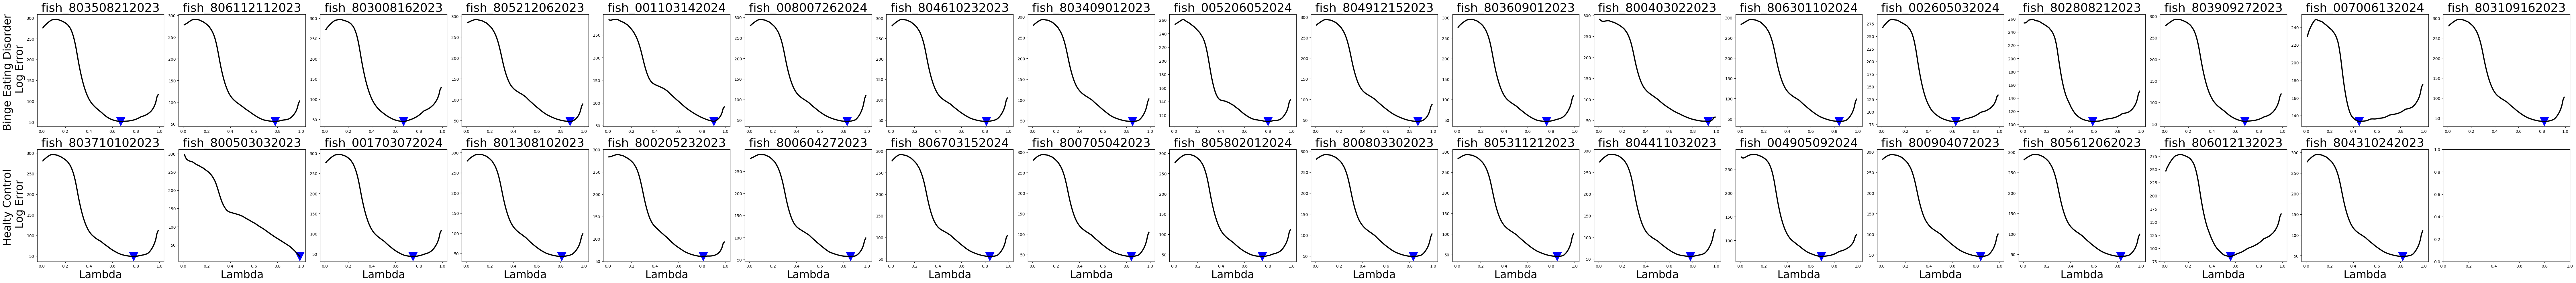

In [7]:
fig, ax = plt.subplots(2, max(n_BE, n_HC), figsize = (90,10))
for n1, name in enumerate(names_BE):
    im = ax[0][n1].plot(lambdas_, iter_errors[n1,:], c = 'black', lw = 3) 
    ax[0][n1].scatter(lambdas_[np.argmin(iter_errors[n1,:])], min(iter_errors[n1,:]), s = 500, marker = 'v', c = 'blue')
    # ax[0][n1].set_xticks([k*5 for k in range(9)])
    # ax[0][n1].set_yticks([k*0.2 for k in range(6)])        
    ax[0][n1].set_title('%s'%name.split('.')[0], fontsize = 30)

for n2, name in enumerate(names_HC):
    im = ax[1][n2].plot(lambdas_, iter_errors[n1+n2+1,:], c = 'black', lw = 3) 
    ax[1][n2].scatter(lambdas_[np.argmin(iter_errors[n1+n2+1,:])], min(iter_errors[n1+n2+1,:]), s = 500, marker = 'v', c = 'blue')
    # ax[1][n2].set_xticks([k*5 for k in range(9)])
    # ax[1][n2].set_yticks([k*0.2 for k in range(6)])        
    ax[1][n2].set_title('%s'%name.split('.')[0], fontsize = 30)
    ax[1][n2].set_xlabel('Lambda', fontsize = 27)
ax[0][0].set_ylabel(f'Binge Eating Disorder \n Log Error', fontsize = 27)
ax[1][0].set_ylabel(f'Healty Control \n Log Error', fontsize = 27)
plt.tight_layout()

Text(0.5, 1.0, 'Free parameter -- $\\lambda$')

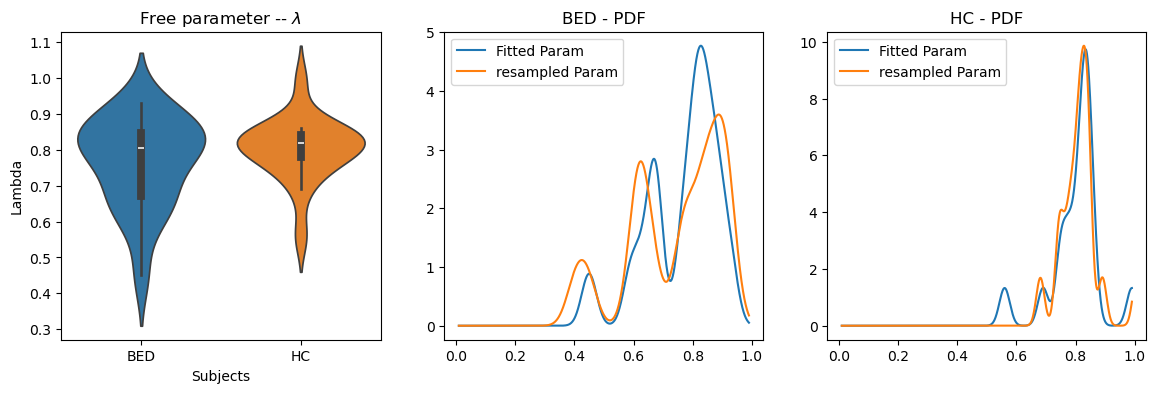

In [76]:
best_param_BE = [best_param['%s'%name.split('.')[0]] for n, name in enumerate(names_BE)]
best_param_HC = [best_param['%s'%name.split('.')[0]] for n, name in enumerate(names_HC)]
resample_size_BE = len(best_param_BE)
resample_size_HC = len(best_param_HC)

eval_size = 10000
eval_lambdas = np.linspace(0.01,0.99,eval_size)
bandwith_factor = 0.2

fig,ax = plt.subplots(1,3,figsize = (14,4))

kernel_BE = gaussian_kde(best_param_BE, bw_method = bandwith_factor)
resamples_BE = kernel_BE.resample(resample_size_BE)
kernel_resample_BE = gaussian_kde(resamples_BE, bw_method = bandwith_factor)

ax[1].plot(eval_lambdas, kernel_BE.evaluate(eval_lambdas), label = 'Fitted Param')
ax[1].plot(eval_lambdas, kernel_resample_BE.evaluate(eval_lambdas), label = 'resampled Param')
ax[1].set_title('BED - PDF', fontsize = 12)
ax[1].legend()

kernel_HC = gaussian_kde(best_param_HC, bw_method = bandwith_factor)
resamples_HC = kernel_HC.resample(resample_size_HC)
kernel_resample_HC = gaussian_kde(resamples_HC, bw_method=bandwith_factor)

ax[2].plot(eval_lambdas, kernel_HC.evaluate(eval_lambdas), label = 'Fitted Param')
ax[2].plot(eval_lambdas, kernel_resample_HC.evaluate(eval_lambdas), label = 'resampled Param')
ax[2].set_title('HC - PDF', fontsize = 12)
ax[2].legend()

params = {'Subjects':['BED' for _ in range(n_BE)]+['HC' for _ in range(n_HC)], 'Lambda':[best_param['%s'%name.split('.')[0]] for n, name in enumerate(names_BE+names_HC)]}
sns.violinplot(data = params, x = 'Subjects', y = 'Lambda', hue = 'Subjects', ax = ax[0])
ax[0].set_title(r'Free parameter -- $\lambda$', fontsize =  12)

### Generate a fake dataset with known best $\lambda$ values and then fit paramaters to that dataset

In [ ]:
sampled_param = {'FakeSubject%d'%n :np.concatenate((resamples_BE[0],resamples_HC[0]))[n] for n in range(resample_size_BE+resample_size_HC)}
df_fake = generate_data_BL(sampled_param, resample_size_BE, resample_size_HC,
                                  df[df.SubjectID == name.split('.')[0]].TrueLabels.to_list(), 
                                  df[df.SubjectID == name.split('.')[0]].ObservedLabel.to_list()) #generate a dataset with the best fit paramaters

In [17]:
lambdas = np.linspace(0.002,0.998,499)

iter_errors_fake = np.zeros((resample_size_BE + resample_size_HC, len(lambdas)))
best_param_fake = {}

for n in range(resample_size_BE + resample_size_HC):
    for l, lmbda in enumerate(lambdas_):
        AGENT = agent(policy = 'BL', lmbda = lmbda)#initialize the artificial agent. ONLY FOR functionality purposes.
        error = np.zeros((nBlocks, nTrials))
        for b in range(nBlocks):
            pondp = AGENT.initialize_prob(nTrials)
            for i in range(nTrials):
                #get the choices from DF
                pred = df_fake[(df_fake.SubjectID == 'FakeSubject%d'%n)&(df_fake.BlockID == b)&(df_fake.TrialID == i)].PredLabels.to_numpy()[0]
                observ = df_fake[(df_fake.SubjectID == 'FakeSubject%d'%n)&(df_fake.BlockID == b)&(df_fake.TrialID == i)].ObservedLabel.to_numpy()[0]
                if i == 0:
                    prior = pondp[i,:] #no prior in the first trial so posterior(t) = prior(t)
                else: 
                    prior = pondp[i-1,:] #prior = posterior(t-1)
                
               #belief update
                den = np.dot(AGENT.llhood[observ,:], prior) #prob of the data under all the hypothesis
                pondp[i,:] = np.multiply(AGENT.llhood[observ,:], prior)/den #likelihood * prior/ sum(likelihood*prior)
                
                prob = pondp[i,:]

                pondp[i,:] = np.maximum(0.05, pondp[i,:]) #we don't want posteiror to get too small and no convergence
                pondp[i,:] = pondp[i,:]/pondp[i,:].sum()
                
                error[b,i] = min(2,abs(np.log(prob[pred])))
                
        iter_errors_fake[n,l] = error.sum() 
    l_ = np.argmin(iter_errors_fake[n,:])
    best_param_fake['FakeSubject%d'%n] = lambdas_[l_]

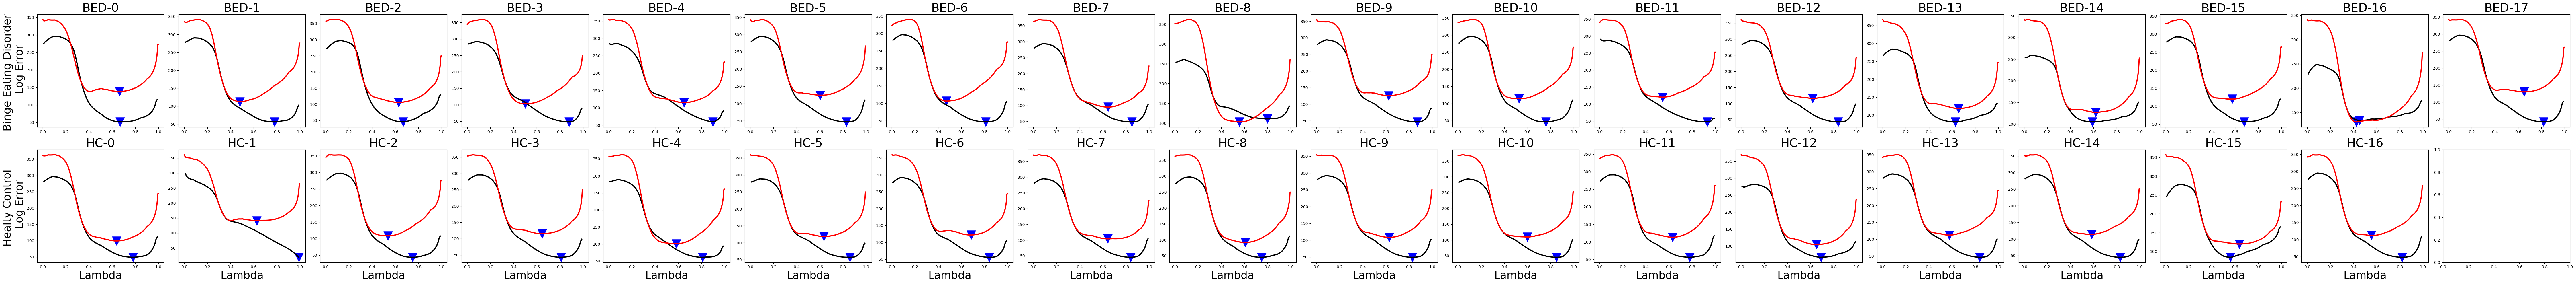

In [37]:
fig, ax = plt.subplots(2, max(n_BE, n_HC), figsize = (90,10))
for n1, name in enumerate(names_BE):
    im = ax[0][n1].plot(np.linspace(0.01,0.99,99), iter_errors[n1,:], c = 'black', lw = 3) 
    ax[0][n1].scatter(np.linspace(0.01,0.99,99)[np.argmin(iter_errors[n1,:])], min(iter_errors[n1,:]), s = 500, marker = 'v', c = 'blue')
    ax[0][n1].plot(lambdas_, iter_errors_fake[n1,:], c = 'red', lw = 3, label = 'fake') 
    ax[0][n1].scatter(lambdas_[np.argmin(iter_errors_fake[n1,:])], min(iter_errors_fake[n1,:]), s = 500, marker = 'v', c = 'blue')
    # ax[0][n1].set_xticks([k*5 for k in range(9)])
    # ax[0][n1].set_yticks([k*0.2 for k in range(6)])        
    ax[0][n1].set_title('BED-%s'%n1, fontsize = 30)

for n2, name in enumerate(names_HC):
    im = ax[1][n2].plot(np.linspace(0.01,0.99,99), iter_errors[n1+n2+1,:], c = 'black', lw = 3) 
    ax[1][n2].scatter(np.linspace(0.01,0.99,99)[np.argmin(iter_errors[n1+n2+1,:])], min(iter_errors[n1+n2+1,:]), s = 500, marker = 'v', c = 'blue')
    ax[1][n2].plot(lambdas_, iter_errors_fake[n1+n2+1,:], c = 'red', lw = 3, label = 'fake') 
    ax[1][n2].scatter(lambdas_[np.argmin(iter_errors_fake[n1+n2+1,:])], min(iter_errors_fake[n1+n2+1,:]), s = 500, marker = 'v', c = 'blue')
    # ax[1][n2].set_xticks([k*5 for k in range(9)])
    # ax[1][n2].set_yticks([k*0.2 for k in range(6)])        
    ax[1][n2].set_title('HC-%s'%n2, fontsize = 30)
    ax[1][n2].set_xlabel('Lambda', fontsize = 27)
ax[0][0].set_ylabel(f'Binge Eating Disorder \n Log Error', fontsize = 27)
ax[1][0].set_ylabel(f'Healty Control \n Log Error', fontsize = 27)
plt.tight_layout()

<Axes: xlabel='Subjects', ylabel='param'>

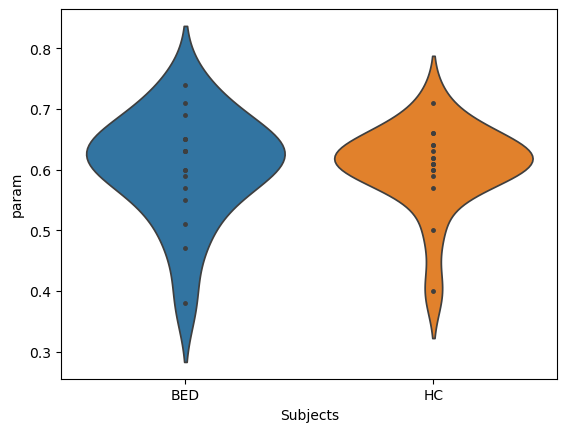

In [44]:
params = {'Subjects':['BED' for _ in range(n_BE)]+['HC' for _ in range(n_HC)], 'param':[best_param_fake['FakeSubject%d'%n] for n, name in enumerate(names_BE+names_HC)]}
sns.violinplot(data = params, x= 'Subjects', y= 'param', hue = 'Subjects', inner = 'point')

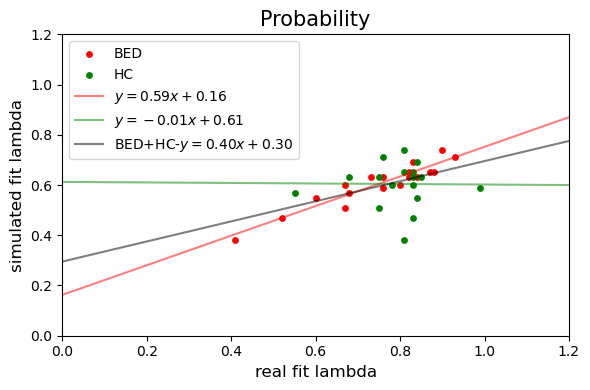

In [17]:
fig, ax = plt.subplots(1,1, figsize = (6,4))
for n, name in enumerate(names_BE):
    sc_bed=ax.scatter(best_param['%s'%(name.split('.')[0])], best_param_fake['FakeSubject%d'%n], s = 15, c = 'red', marker = 'o', label = 'BED')
for n, name in enumerate(names_HC):
    sc_hc=ax.scatter(best_param['%s'%(name.split('.')[0])], best_param_fake['FakeSubject%d'%n], s = 15, c = 'green', marker = 'o', label = 'HC')

ax.set_xlabel(f'real fit lambda', fontsize = 12)
ax.set_ylabel(f'simulated fit lambda', fontsize = 12)
ax.set_title('Probability', fontsize = 15)
ax.set_xlim(0,1.2)
ax.set_ylim(0,1.2)

x_bed = [best_param['%s'%(name.split('.')[0])] for name in (names_BE)]
y_bed = [best_param_fake['FakeSubject%d'%n] for n in range(len(names_BE))]
m_bed, b_bed = np.polyfit(x_bed, y_bed, deg=1)
l_bed = ax.axline(xy1=(0, b_bed), slope=m_bed, color='red', alpha = 0.5)

x_hc = [best_param['%s'%(name.split('.')[0])] for name in (names_HC)]
y_hc = [best_param_fake['FakeSubject%d'%(n+len(names_BE))] for n in range(len(names_HC))]
m_hc, b_hc = np.polyfit(x_hc, y_hc, deg=1)
l_hc = ax.axline(xy1=(0, b_hc), slope=m_hc, color='green', alpha = 0.5)

x = [best_param['%s'%(name.split('.')[0])] for name in (names_BE+names_HC)]
y = [best_param_fake['FakeSubject%d'%n] for n in range(len(names_BE)+len(names_HC))]
m, b = np.polyfit(x, y, deg=1)
l = ax.axline(xy1=(0, b), slope=m, color='black', alpha = 0.5)
ax.legend(handles = [sc_bed, sc_hc, l_bed, l_hc, l], labels = ['BED', 'HC', f'$y = {m_bed:.2f}x {b_bed:+.2f}$', f'$y = {m_hc:.2f}x {b_hc:+.2f}$', f'BED+HC-$y = {m:.2f}x {b:+.2f}$'])

plt.tight_layout()